# CodeAlpha Internship — Task 4
## Sentiment Analysis of Amazon Customer Reviews

### Objective

The objective of this task is to analyze Amazon customer reviews
using Natural Language Processing (NLP) techniques and sentiment
lexicons.

The reviews will be classified into Positive, Negative, and Neutral
sentiments to understand customer opinions, sentiment patterns,
and useful business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd

df = pd.read_csv(
   r"C:\Users\shita\OneDrive\Desktop\CodeAlpha_EDA\Reviews.csv",
    nrows=10000
)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (10000, 10)


In [4]:
df = df[['Score', 'Summary', 'Text']]

df.head()

,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['Text'].apply(clean_text)

df[['Text', 'clean_text']].head()

,Text,clean_text
0,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...
2,This is a confection that has been around a fe...,this is a confection that has been around a fe...
3,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...
4,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide ...


In [6]:
!pip install vaderSentiment

In [10]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['clean_text'].apply(get_sentiment)

df[['clean_text', 'Sentiment']].head()

,clean_text,Sentiment
0,i have bought several of the vitality canned d...,Positive
1,product arrived labeled as jumbo salted peanut...,Negative
2,this is a confection that has been around a fe...,Positive
3,if you are looking for the secret ingredient i...,Positive
4,great taffy at a great price there was a wide ...,Positive


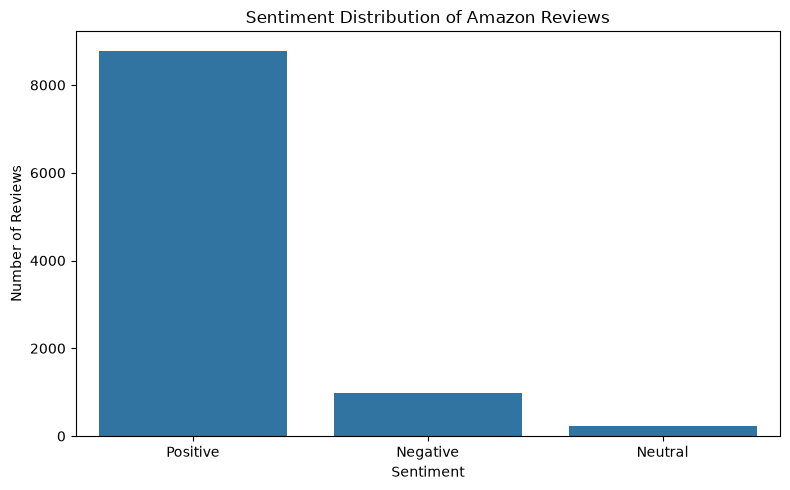

In [11]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title('Sentiment Distribution of Amazon Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.tight_layout()

plt.savefig(
    r"C:\Users\shita\OneDrive\Desktop\CodeAlpha_EDA\sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insights

- The sentiment analysis classified Amazon customer reviews into Positive, Negative, and Neutral categories.
- Positive reviews represent the dominant sentiment in the analyzed dataset.
- Negative reviews represent a smaller portion of the reviews.
- Neutral reviews indicate reviews with relatively balanced or less clearly expressed sentiment.
- The sentiment distribution provides an overview of customer opinions about the reviewed products.

## Conclusion

Sentiment analysis was performed on Amazon customer reviews using
Natural Language Processing and the VADER sentiment lexicon.

The reviews were classified into Positive, Negative, and Neutral
sentiments. The visualization helped identify the overall sentiment
pattern of customers.

This analysis can help businesses understand customer feedback and
identify overall customer satisfaction trends.